In [15]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.impute import SimpleImputer
import warnings
warnings.filterwarnings('ignore')

# Load dataset
'''here i used e-commerce dataset containing around 1000 customer transaction records,loaded the dataset using pandas 
   and understanded the existing columns in the dataset '''

df = pd.read_csv('C:/Users/reddy/Downloads/Ecommerce_Consumer_Behavior_Analysis_Data.csv')

# Displaying basic information
print(df.head())
print(df.info())


   Customer_ID  Age  Gender Income_Level Marital_Status Education_Level  \
0  37-611-6911   22  Female       Middle        Married      Bachelor's   
1  29-392-9296   49    Male         High        Married     High School   
2  84-649-5117   24  Female       Middle         Single        Master's   
3  48-980-6078   29  Female       Middle         Single        Master's   
4  91-170-9072   33  Female       Middle        Widowed     High School   

  Occupation  Location     Purchase_Category Purchase_Amount  ...  \
0     Middle      Évry  Gardening & Outdoors        $333.80   ...   
1       High  Huocheng      Food & Beverages        $222.22   ...   
2       High    Huzhen       Office Supplies        $426.22   ...   
3     Middle    Wiwilí       Home Appliances        $101.31   ...   
4     Middle      Nara             Furniture        $211.70   ...   

   Customer_Satisfaction Engagement_with_Ads  Device_Used_for_Shopping  \
0                      7                 NaN                

In [16]:

# Data Cleaning
'''handled the missing values in the dataset filled the null values with most occured values,changing datatypes of the  existing columns,
   finally checked missing values across all columns in the dataset '''

# Convert purchase amount to numeric
df['Purchase_Amount'] = df['Purchase_Amount'].replace('[\$,]', '', regex=True).astype(float)

# Convert date column
df['Time_of_Purchase'] = pd.to_datetime(df['Time_of_Purchase'])

# Handle missing values
categorical_cols = df.select_dtypes(include='object').columns

for col in categorical_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

# Check missing values
print(df.isnull().sum())


Customer_ID                              0
Age                                      0
Gender                                   0
Income_Level                             0
Marital_Status                           0
Education_Level                          0
Occupation                               0
Location                                 0
Purchase_Category                        0
Purchase_Amount                          0
Frequency_of_Purchase                    0
Purchase_Channel                         0
Brand_Loyalty                            0
Product_Rating                           0
Time_Spent_on_Product_Research(hours)    0
Social_Media_Influence                   0
Discount_Sensitivity                     0
Return_Rate                              0
Customer_Satisfaction                    0
Engagement_with_Ads                      0
Device_Used_for_Shopping                 0
Payment_Method                           0
Time_of_Purchase                         0
Discount_Us

In [8]:

# Feature Engineering
'''created new features like loyalty score,purchase frequency,churn risk based on customer behavior these features may help in segmentation analysis'''

# Monthly purchase extraction
df['Purchase_Month'] = df['Time_of_Purchase'].dt.month

# Loyalty score
df['Loyalty_Score'] = (
    df['Brand_Loyalty'] +
    df['Customer_Satisfaction'] +
    df['Product_Rating']
) / 3

# Churn Risk
df['Churn_Risk'] = np.where(
    (df['Customer_Satisfaction'] < 5) &
    (df['Frequency_of_Purchase'] < 3),
    'High Risk',
    'Low Risk'
)

print(df[['Loyalty_Score', 'Churn_Risk']].head())


   Loyalty_Score Churn_Risk
0       5.666667   Low Risk
1       3.000000   Low Risk
2       5.666667   Low Risk
3       1.666667   Low Risk
4       5.666667   Low Risk


In [17]:

# Customer Segmentation using K-Means
'''applied k-means clustering to group similar customers based on spending and purchasing behavior'''

features = df[['Purchase_Amount', 'Frequency_of_Purchase',
               'Customer_Satisfaction', 'Brand_Loyalty']]

scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

kmeans = KMeans(n_clusters=4, random_state=42)
df['Segment'] = kmeans.fit_predict(scaled_features)

# Segment summary
segment_profile = df.groupby('Segment')[
    ['Purchase_Amount', 'Frequency_of_Purchase',
     'Customer_Satisfaction', 'Brand_Loyalty']
].mean()

print(segment_profile)


         Purchase_Amount  Frequency_of_Purchase  Customer_Satisfaction  \
Segment                                                                  
0             300.354984               5.367213               2.659016   
1             271.451654               4.150000               7.880769   
2             298.070597              10.024876               6.800995   
3             226.350385               9.461538               5.008547   

         Brand_Loyalty  
Segment                 
0             2.668852  
1             3.126923  
2             1.776119  
3             4.452991  


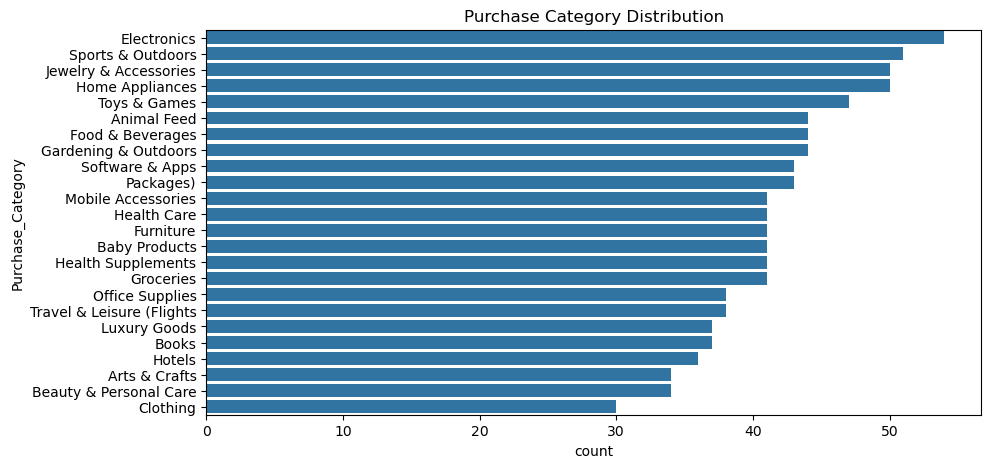

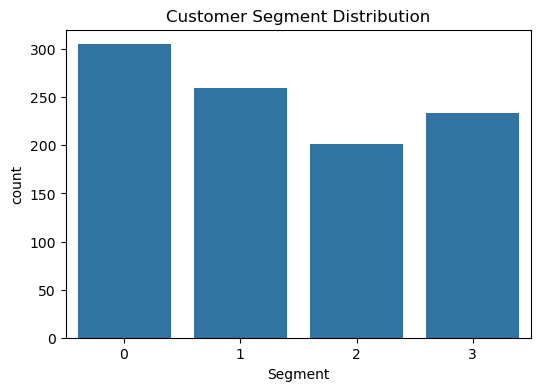

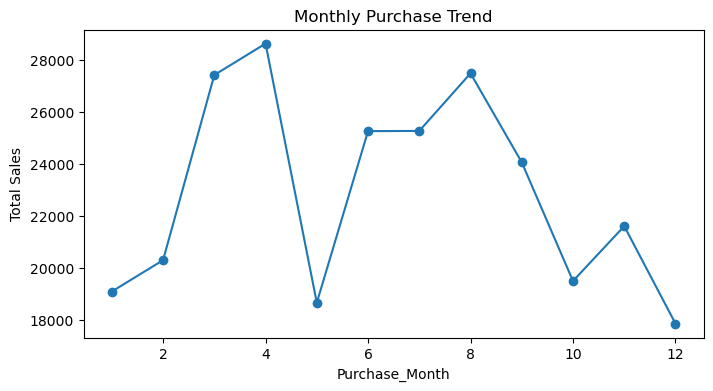

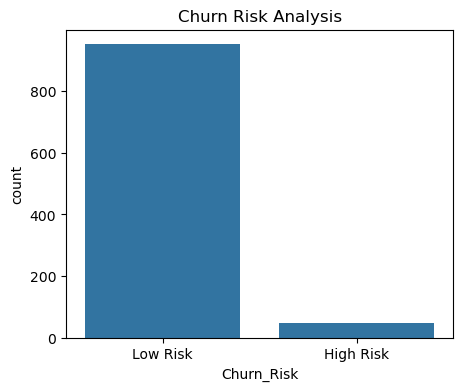

In [10]:
# Purchase Category Distribution
plt.figure(figsize=(10,5))
sns.countplot(y=df['Purchase_Category'],
              order=df['Purchase_Category'].value_counts().index)
plt.title('Purchase Category Distribution')
plt.show()

# Segment Distribution
plt.figure(figsize=(6,4))
sns.countplot(x=df['Segment'])
plt.title('Customer Segment Distribution')
plt.show()

# Monthly Purchase Trend
monthly_sales = df.groupby('Purchase_Month')['Purchase_Amount'].sum()

plt.figure(figsize=(8,4))
monthly_sales.plot(marker='o')
plt.title('Monthly Purchase Trend')
plt.ylabel('Total Sales')
plt.show()

# Churn Risk Count
plt.figure(figsize=(5,4))
sns.countplot(x=df['Churn_Risk'])
plt.title('Churn Risk Analysis')
plt.show()


In [ ]:

# Recommendations for Alfido Tech

''' 1. Launch personalized campaigns for high-value customer segments.
    2. Improve retention programs for high churn-risk customers.
    3. Increase targeted advertisements on frequently purchased categories.
    4. Provide loyalty rewards and discounts for repeat buyers.
    5. Optimize shopping experience for smartphone users, as mobile purchases dominate.'''

# Conclusion

'''This analysis identified customer behavior trends, segmented customers using clustering, and highlighted churn-risk groups. The insights can help Alfido Tech improve engagement,
retention, and revenue generation through data-driven strategies.'''

